# Colormap 实验数据分析

- 数据预处理（RT 过滤、对数变换、控制试次剔除）
- 可视化：正确率/反应时间与频率、亮度模式的交互
- 统计建模：LMM（RT）、GEE（正确率）、随机森林（指标重要性）
- 论文要点：亮度指标的频率依赖性、LumaPattern×Frequency 交互效应

## 1. 导入与加载数据

In [30]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

FIG_DIR = "output_images"
os.makedirs(FIG_DIR, exist_ok=True)

# 加载原始数据，剔除控制试次 (trialId 9000–9003)
df = pd.read_csv("output_data/result_all_participants.csv")
df = df[~df["trialId"].isin([9000, 9001, 9002, 9003])].copy()
df = df.rename(columns={"reactionTimeMs": "reactionTime"})
df = df.rename(columns={"isCorrect": "correct"})

df.shape

(1872, 32)

## 2. 数据预处理（定义函数并执行）

In [31]:
def preprocess(df):
    """RT 按参与者 ±2 SD 修剪，log_RT，色卡因子与频率编码为类别。"""
    rt_mean = df.groupby("participantId")["reactionTime"].transform("mean")
    rt_std = df.groupby("participantId")["reactionTime"].transform("std")
    within_2sd = (df["reactionTime"] >= rt_mean - 2 * rt_std) & (df["reactionTime"] <= rt_mean + 2 * rt_std)
    keep = within_2sd | rt_std.isna() | (rt_std == 0)
    df_clean = df.loc[keep].copy()
    print(len(df), "original", len(df_clean), "after RT pruning, removed", len(df) - len(df_clean), "rows")

    df_clean["log_RT"] = np.log(df_clean["reactionTime"])

    freq_order = ["low", "medium", "high"]
    df_clean["frequencyId"] = pd.Categorical(df_clean["frequencyId"], categories=freq_order, ordered=True)
    pattern_order = ["constant", "linear", "thermal", "diverging"]
    df_clean["colormapLumaPattern"] = pd.Categorical(df_clean["colormapLumaPattern"], categories=pattern_order, ordered=False)
    df_clean["colormapChromaPattern"] = pd.Categorical(df_clean["colormapChromaPattern"], categories=pattern_order, ordered=False)
    df_clean["colormapHue"] = pd.Categorical(df_clean["colormapHue"], categories=[100, 200, 300], ordered=False)
    return df_clean

df_clean = preprocess(df)

1872 original 1767 after RT pruning, removed 105 rows


## 3. VIF（多重共线性）

In [32]:
def run_vif(df_clean, METRICS):
    """
    计算各颜色指标之间的方差膨胀因子 (VIF)。

    VIF 越大说明该变量能被其它自变量线性解释的程度越高，共线性越严重。
    若 VIF > 10，通常认为共线性较强，回归模型中可考虑剔除或只保留其中一个。

    用法: run_vif(df_clean)
    参数: df_clean: 已预处理的 DataFrame，需含 METRICS 中的列
    """
    print("--- Variance Inflation Factor (VIF) ---")
    X = df_clean[METRICS].dropna()
    if len(X) < 2:
        print("样本不足，跳过 VIF")
        return
    # StandardScaler: 每列减均值、除标准差，使量纲统一，VIF 计算更稳定
    X_scaled = StandardScaler().fit_transform(X)
    vif_data = pd.DataFrame()
    vif_data["feature"] = METRICS
    # variance_inflation_factor(X, i): 计算第 i 列相对其余列回归时的 VIF
    vif_data["VIF"] = [
        variance_inflation_factor(X_scaled, i) for i in range(len(METRICS))
    ]
    print(vif_data)
    print("(若 VIF > 10，建模时可考虑只保留其一)\n")

In [33]:
METRICS = [
    "log_ciede2000_discriminative", "log_contrast_sensitivity",
    "log_hue_discriminative", "log_luminance_variation", "log_chromatic_variation",
    "log_categorization", 
    # "logLAB_Length",
     "log_color_name_variation"
]
FREQ_ORDER = ["low", "medium", "high"]
run_vif(df_clean, METRICS)

--- Variance Inflation Factor (VIF) ---
                        feature       VIF
0  log_ciede2000_discriminative  5.796525
1      log_contrast_sensitivity  9.661672
2        log_hue_discriminative  3.796287
3       log_luminance_variation  6.299106
4       log_chromatic_variation  1.812898
5            log_categorization  3.351086
6      log_color_name_variation  1.975869
(若 VIF > 10，建模时可考虑只保留其一)



In [28]:
METRICS = [
    "ciede2000_discriminative",  # 基于 CIEDE2000 的色差判别力
    "contrast_sensitivity",       # 对比敏感度
    "hue_discriminative",        # 色相判别力
    "luminance_variation",       # 亮度变化
    "chromatic_variation",       # 色度变化
    "categorization",            # 可分类数
    # "LAB_Length",                 # LAB 空间路径长度
    "color_name_variation"        # 颜色名称差异
]
FREQ_ORDER = ["low", "medium", "high"]
run_vif(df_clean, METRICS)

--- Variance Inflation Factor (VIF) ---
                    feature        VIF
0  ciede2000_discriminative   6.491172
1      contrast_sensitivity  10.268596
2        hue_discriminative   2.911168
3       luminance_variation   8.474760
4       chromatic_variation   1.492848
5            categorization   4.244221
6      color_name_variation   2.449992
(若 VIF > 10，建模时可考虑只保留其一)



## 4. 可视化

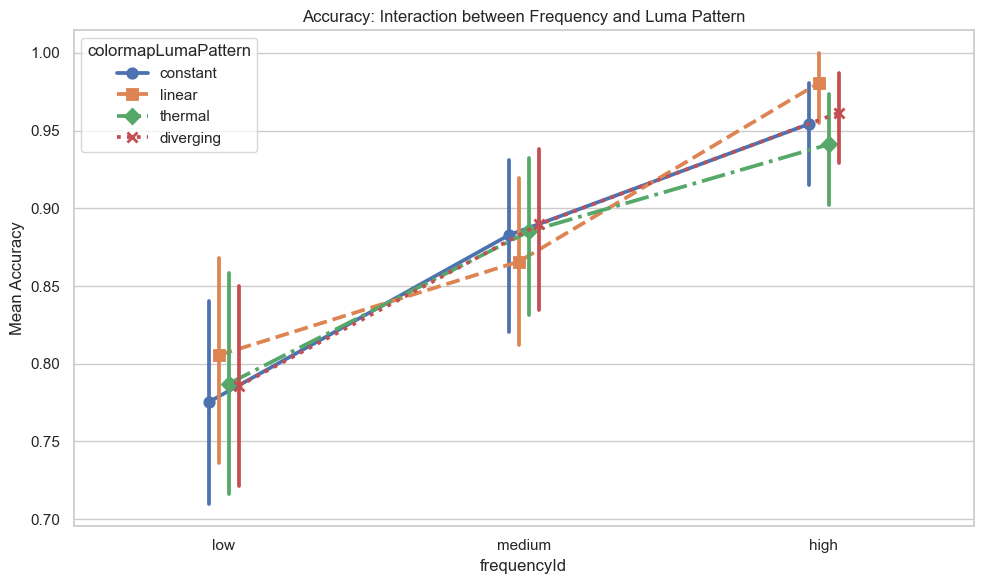

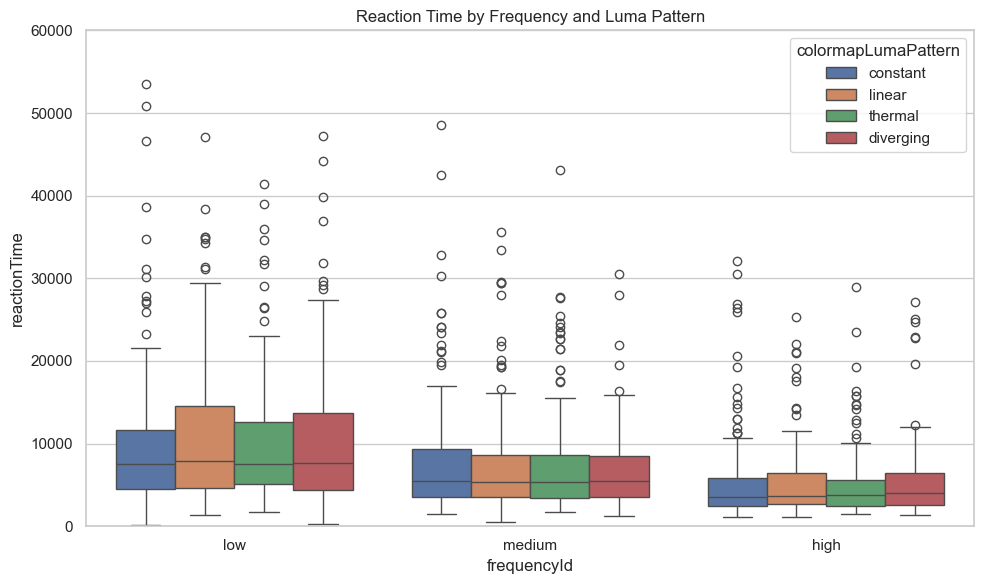

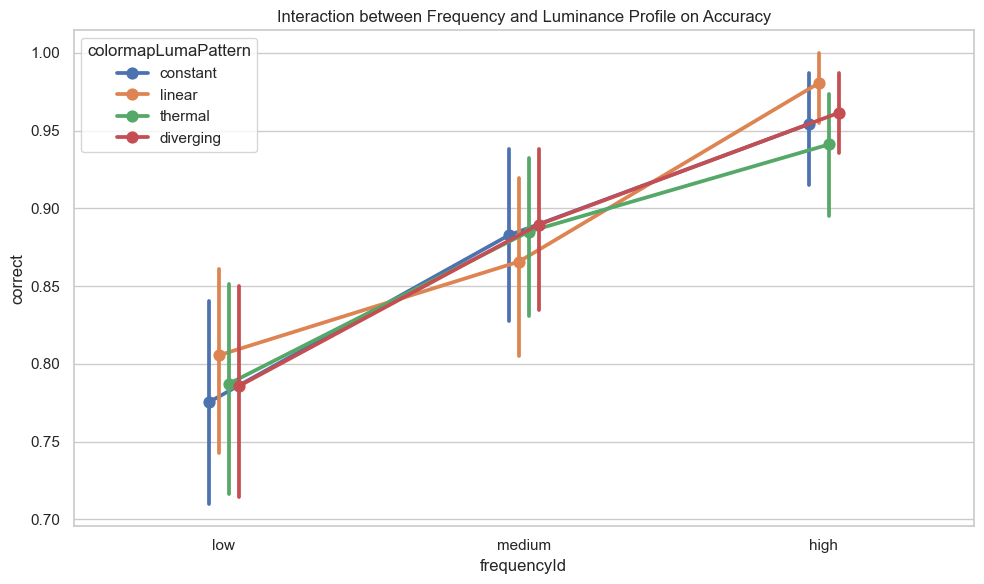

/var/folders/3x/rc15snxx1rv3hf_87dljrn4h0000gn/T/ipykernel_14004/3385151063.py:28: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df_clean.pivot_table(values="correct", index="colormapLumaPattern", columns="frequencyId", aggfunc="mean")


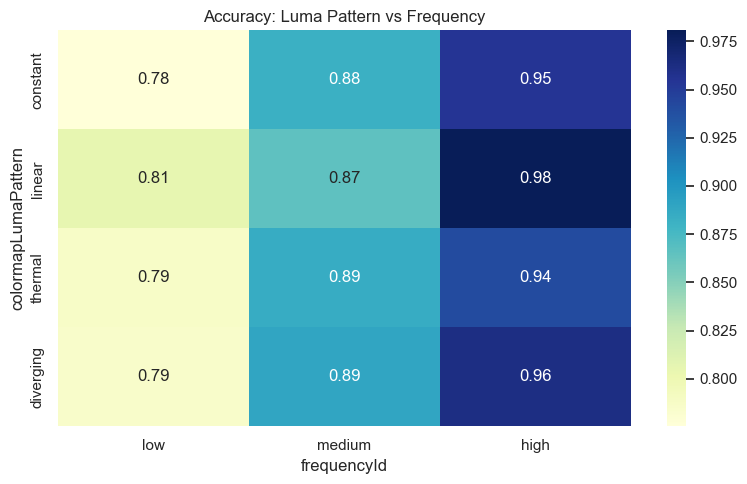

In [35]:
def run_visualizations(df_clean):
    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(10, 6))
    sns.pointplot(data=df_clean, x="frequencyId", y="correct", hue="colormapLumaPattern",
                  markers=["o", "s", "D", "x"], linestyles=["-", "--", "-.", ":"], dodge=True)
    plt.title("Accuracy: Interaction between Frequency and Luma Pattern")
    plt.ylabel("Mean Accuracy")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "accuracy_interaction.png"), dpi=150)
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_clean, x="frequencyId", y="reactionTime", hue="colormapLumaPattern")
    plt.title("Reaction Time by Frequency and Luma Pattern")
    plt.ylim(0, 60000)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "rt_distribution.png"), dpi=150)
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.pointplot(data=df_clean, x="frequencyId", y="correct", hue="colormapLumaPattern", dodge=True)
    plt.title("Interaction between Frequency and Luminance Profile on Accuracy")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "interaction_plot.png"), dpi=150)
    plt.show()

    pivot_table = df_clean.pivot_table(values="correct", index="colormapLumaPattern", columns="frequencyId", aggfunc="mean")
    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".2f")
    plt.title("Accuracy: Luma Pattern vs Frequency")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "luma_pattern_vs_frequency.png"), dpi=150)
    plt.show()

run_visualizations(df_clean)

## 5. LMM（反应时间）

In [10]:
formula = "log_RT ~ C(colormapLumaPattern) * C(frequencyId) + C(colormapChromaPattern) + C(colormapHue)"
rt_model = smf.mixedlm(formula, df_clean, groups=df_clean["participantId"])
rt_results = rt_model.fit()
print(rt_results.summary())

                                 Mixed Linear Model Regression Results
Model:                            MixedLM                 Dependent Variable:                 log_RT    
No. Observations:                 1767                    Method:                             REML      
No. Groups:                       39                      Scale:                              0.3884    
Min. group size:                  43                      Log-Likelihood:                     -1751.0424
Max. group size:                  47                      Converged:                          Yes       
Mean group size:                  45.3                                                                  
--------------------------------------------------------------------------------------------------------
                                                             Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------

## 6. GEE（正确率）

In [11]:
formula = "correct ~ C(colormapLumaPattern) * C(frequencyId) + C(colormapChromaPattern) + C(colormapHue)"
acc_model = sm.GEE.from_formula(formula, groups=df_clean["participantId"], data=df_clean, family=sm.families.Binomial())
acc_results = acc_model.fit()
print(acc_results.summary())

interaction_params = [k for k in acc_results.pvalues.index if "colormapLumaPattern" in k and "frequencyId" in k and ":" in k]
if interaction_params:
    sig = (acc_results.pvalues[interaction_params] < 0.05).any()
    print("\n[论文要点] LumaPattern × Frequency 交互", "显著" if sig else "未达显著")

                               GEE Regression Results                              
Dep. Variable:                     correct   No. Observations:                 1767
Model:                                 GEE   No. clusters:                       39
Method:                        Generalized   Min. cluster size:                  43
                      Estimating Equations   Max. cluster size:                  47
Family:                           Binomial   Mean cluster size:                45.3
Dependence structure:         Independence   Num. iterations:                     2
Date:                     Sat, 07 Mar 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         23:05:12
                                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------

## 7. Logit（正确率）

In [12]:
formula = "correct ~ C(colormapLumaPattern) * C(frequencyId) + C(colormapChromaPattern) + C(colormapHue)"
logit_results = smf.logit(formula, data=df_clean).fit(disp=0)
print(logit_results.summary())

                           Logit Regression Results                           
Dep. Variable:                correct   No. Observations:                 1767
Model:                          Logit   Df Residuals:                     1750
Method:                           MLE   Df Model:                           16
Date:                Sat, 07 Mar 2026   Pseudo R-squ.:                 0.07305
Time:                        23:05:12   Log-Likelihood:                -604.60
converged:                       True   LL-Null:                       -652.25
Covariance Type:            nonrobust   LLR p-value:                 2.614e-13
                                                                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------
Intercept                                                        1.4665      0.267      5.502      0.000      

## 8. 随机森林（按频率的特征重要性）

In [36]:
for freq in FREQ_ORDER:
    subset = df_clean[df_clean["frequencyId"] == freq].dropna(subset=METRICS + ["correct"])
    if len(subset) < 50:
        print(f"[{freq}] 样本不足")
        continue
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(subset[METRICS], subset["correct"])
    importance = pd.Series(rf.feature_importances_, index=METRICS).sort_values(ascending=False)
    print(f"Top 3 for [{freq}]:")
    print(importance.head(3), "\n")

Top 3 for [low]:
log_chromatic_variation    0.180286
log_categorization         0.159001
log_hue_discriminative     0.154550
dtype: float64 

Top 3 for [medium]:
log_ciede2000_discriminative    0.193909
log_color_name_variation        0.153164
log_chromatic_variation         0.140895
dtype: float64 

Top 3 for [high]:
log_luminance_variation     0.193366
log_categorization          0.146181
log_contrast_sensitivity    0.143021
dtype: float64 

